In [3]:
import tensorflow as tf
print("Tensorflow implemented")

from keras.models import Sequential
print("keras implemented")

from keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

import matplotlib.pyplot as plt

Tensorflow implemented
keras implemented


In [4]:
(X_train,y_train),(X_test,y_test)=(
    tf.keras.datasets.mnist.load_data()
)

print(X_train.shape)

(60000, 28, 28)


In [5]:
X_train = X_train.reshape(
    -1,28,28,1
)/255.0

X_test = X_test.reshape(
    -1,28,28,1
)/255.0

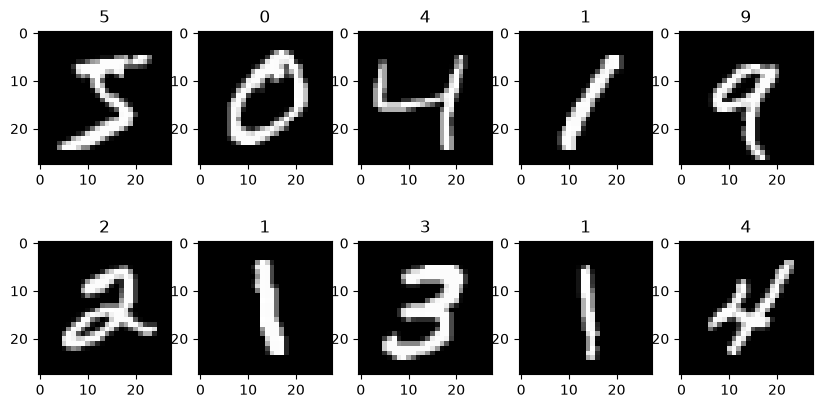

In [6]:
plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(
        X_train[i].reshape(28,28),
        cmap="gray"
    )

    plt.title(y_train[i])

plt.show()

In [7]:
###CNN Architecture

model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(28,28,1)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        10,
        activation="softmax"
    )
])

c:\Users\ShrutishreePanda\ai-training-journey\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=64
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9331 - loss: 0.2195 - val_accuracy: 0.9818 - val_loss: 0.0599
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9793 - loss: 0.0681 - val_accuracy: 0.9871 - val_loss: 0.0460
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9850 - loss: 0.0485 - val_accuracy: 0.9902 - val_loss: 0.0360
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9883 - loss: 0.0375 - val_accuracy: 0.9901 - val_loss: 0.0366
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9904 - loss: 0.0302 - val_accuracy: 0.9895 - val_loss: 0.0405


In [10]:
test_loss,test_acc = model.evaluate(
    X_test,
    y_test
)

print(
    "Test Accuracy:",
    test_acc
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9900 - loss: 0.0314
Test Accuracy: 0.9900000095367432


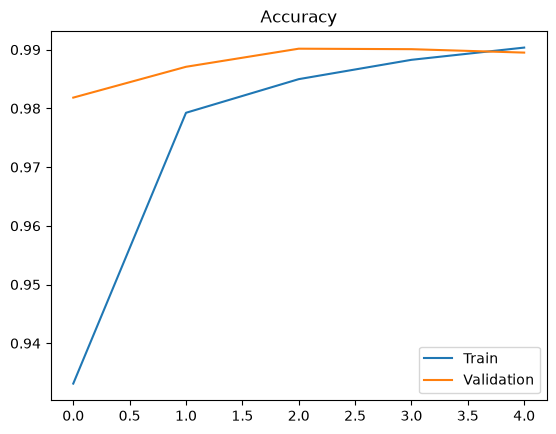

In [11]:
###Accuracy graph

plt.plot(
    history.history["accuracy"]
)

plt.plot(
    history.history["val_accuracy"]
)

plt.legend([
    "Train",
    "Validation"
])

plt.title("Accuracy")
plt.show()